<a href="https://colab.research.google.com/github/AndreiDragomir07/COS484_A1_P2/blob/main/Andrei_Dragomir_A1P2_Classification_(COS484_S2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for Programming Question 2
Welcome to the programming portion of the assignment! Each assignment throughout the semester will have a written portion and a programming portion. We will be using [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb#recent=true), so if you have never used it before, take a quick look through this introduction: [Working with Google Colab](https://docs.google.com/document/d/1LlnXoOblXwW3YX-0yG_5seTXJsb3kRdMMRYqs8Qqum4/edit?usp=sharing).

We'll also be programming in Python, which we will assume a basic familiarity with. Python has fantastic community support and we'll be using numerous packages for machine learning (ML) and natural language processing (NLP) tasks.

### Learning Objectives
In this problem we will implement logistic regression and test it on a sentiment analysis dataset.

### Data Loading and Feature Extraction

##### You will need to implement a method that processes raw text into feature vectors by mapping vocabulary terms to unique indices. Your implementation needs to support Unigram extraction, where features represent individual word counts, as well as Bigram extraction, where features represent consecutive word pair counts. Make sure your setup correctly handles feature indexing so that the same mapping is applied to both training and development data.

### Model Implementation

You should implement a class that supports the logistic regression logic. This includes:
*   **Initialization**: A function to initialize the model parameters (weights and biases) as well as hyperparameters (including the learning rate, regularization parameter, and number of epochs).
*   **Optimization**: A training method that iterates through the dataset, calculates the gradient of the loss function for each example or batch, and updates the parameters using your chosen optimization function (we suggest using Stochastic Gradient Descent or Mini-batch SGD for efficiency).
*   **Inference**: A function that outputs the model's prediction for a single example.

### Training Loop

You should implement the logic for your model to train on the given training examples. Experiment with different hyperparameters to find the ones that optimize performance.

### Functions for evaluating model accuracy

### Download and load the training and development data

You can download the training and development sets for this problem from the links below:
*   Training data: https://princeton-nlp.github.io/cos484/assignments/a1/train.txt
*   Development data: https://princeton-nlp.github.io/cos484/assignments/a1/dev.txt

In [1]:
import requests

def load_dataset(url):
    """
    Loads a dataset from a given URL, parsing each line into a label and a list of tokens.
    Skips the label (0 or 1) at the beginning of each line.

    Args:
        url (str): The URL of the dataset.

    Returns:
        list: A list of tuples, where each tuple contains (label, list_of_tokens).
              Labels are integers (0 or 1), and tokens are strings.
    """
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for HTTP errors
    lines = response.text.strip().split('\n')

    parsed_data = []
    review_count = 0 # Initialize review counter
    for line in lines:
        if not line:  # Skip empty lines
            continue

        parts = line.split(' ', 1) # Split only on the first space
        if len(parts) < 2:
            # Handle lines that might only contain a label or are malformed
            continue

        label_str = parts[0]
        text_str = parts[1]

        try:
            label = int(label_str)
            # Tokenize by whitespace. The text is already pre-tokenized by whitespace as per instructions.
            tokens = text_str.split()
            parsed_data.append((label, tokens))
            review_count += 1 # Increment counter for each successfully parsed review
        except ValueError:
            # Skip lines where label is not an integer
            continue

    print(f"Loaded {review_count} reviews from {url}") # Print the review count
    return parsed_data

training_tokens = load_dataset("https://princeton-nlp.github.io/cos484/assignments/a1/train.txt")
development_tokens = load_dataset("https://princeton-nlp.github.io/cos484/assignments/a1/dev.txt")

print(training_tokens)

Loaded 6920 reviews from https://princeton-nlp.github.io/cos484/assignments/a1/train.txt
Loaded 872 reviews from https://princeton-nlp.github.io/cos484/assignments/a1/dev.txt
[(1, ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're-imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']), (0, ['apparently', 'reassembled', 'from', 'the', 'cutting-room', 'floor', 'of', 'any', 'given', 'daytime', 'soap', '.']), (0, ['they', 'presume', 'their', 'audience', 'wo', "n't", 'sit', 'still', 'for', 'a', 'sociology', 'lesson', ',', 'however', 'entertainingly', 'presented', ',', 'so', 'they', 'trot', 'out', 'the', 'conventional', 'science-fiction', 'elements', 'of', 'bug-eyed', 'monsters', 'and', 'futuristic', 'women', 'in', 'skimpy', 'clothes', '.']), (1, ['this', 'is', 'a', 'visually', 'stunning', 'rumination', 'on', 'love', ',', 'memory', ',', 'history', 'and', 'the', 'war', 'between', 'art', 'and', 'commerce', '.']), (1, ['jonathan', 'parker', "'s

# Experiments

### Unigram vs Bigram (No regularization)
Code for sub-part (a)

In [2]:
import numpy as np
import scipy.sparse as sp # Import scipy.sparse

class FeatureExtraction:
    def __init__(self):
        self.token_to_idx = {}
        self.idx_to_token = []
        self.bigram_to_idx = {} # key is tuple representing bigram,
        # value is index in bigram vocabulary
        self.idx_to_bigram = []
        self.unigram_vocab_size = 0
        self.bigram_vocab_size = 0

    def build_vocabulary(self, training_tokens):
        """
        Builds the unigram and bigram vocabularies
        from a list of tokenized texts.

        Args:
            training_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
        for review in training_tokens:
            for token in review[1]: # review[1] contains the list of tokens
                if token not in self.token_to_idx:
                    self.token_to_idx[token] = self.unigram_vocab_size
                    self.idx_to_token.append(token)
                    self.unigram_vocab_size += 1
        print(f"Unigram vocabulary built with {self.unigram_vocab_size} unique tokens.")

        # Implement a loop to also build the bigram vocabulary present
        # in the training dataset
        for review in training_tokens:
            tokens_list = review[1]
            for i in range(len(tokens_list) - 1):
                token1 = tokens_list[i]
                token2 = tokens_list[i+1]
                bigram = (token1, token2)
                if bigram not in self.bigram_to_idx:
                    self.bigram_to_idx[bigram] = self.bigram_vocab_size
                    self.idx_to_bigram.append(bigram)
                    self.bigram_vocab_size += 1
        print(f"Bigram vocabulary built with {self.bigram_vocab_size} unique bigrams.")

    def unigram_extraction(self, input_tokens):
        """
        Maps a given dataset onto a unigram array, which transforms
        all datapoints into a tuple consisting of an integer (0 or 1) and then
        a sparse numpy array representing the counts of each of the tokens in
        the unigram vocabulary that appear in the given datapoint

        Checks whether a token read can be found in the vocabulary. If it
        cannot be found, dismiss it

        Args:
            self
            input_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
        extracted_features = []
        for label, tokens_list in input_tokens:
            # Use a dictionary to store unigram counts efficiently before converting to sparse format
            unigram_counts_dict = {}
            for token in tokens_list:
                if token in self.token_to_idx:
                    idx = self.token_to_idx[token]
                    unigram_counts_dict[idx] = unigram_counts_dict.get(idx, 0) + 1

            # Create a sparse vector (CSR matrix with 1 row) from the dictionary
            indices = np.array(list(unigram_counts_dict.keys()))
            data = np.array(list(unigram_counts_dict.values()))

            if len(indices) > 0:
                sparse_feature_vector = sp.csr_matrix((data, (np.zeros_like(indices), indices)),
                                                      shape=(1, self.unigram_vocab_size),
                                                      dtype=int)
            else:
              # Handle cases where there are no unigrams for a document
                sparse_feature_vector = sp.csr_matrix((1, self.unigram_vocab_size), dtype=int)

            extracted_features.append((label, sparse_feature_vector))
        return extracted_features


    def bigram_extraction(self, input_tokens):
      """
        Maps a given dataset onto a bigram array, which transforms
        all datapoints into a tuple consisting of an integer (0 or 1) and then
        a sparse numpy array representing the counts of each of the bigrams
        that appear in the given datapoint

        Checks whether a token read can be found in the vocabulary. If it
        cannot be found, dismiss it

        Args:
            self
            input_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
      extracted_features = []
      for label, tokens_list in input_tokens:
          # Use a dictionary to store bigram counts efficiently before converting to sparse format
          bigram_counts_dict = {}
          for i in range(len(tokens_list) - 1):
              token1 = tokens_list[i]
              token2 = tokens_list[i+1]

              bigram = (token1, token2)
              if bigram in self.bigram_to_idx:
                  idx = self.bigram_to_idx[bigram]
                  bigram_counts_dict[idx] = bigram_counts_dict.get(idx, 0) + 1

          # Create a sparse vector (CSR matrix with 1 row) from the dictionary
          indices = np.array(list(bigram_counts_dict.keys()))
          data = np.array(list(bigram_counts_dict.values()))

          if len(indices) > 0:
            sparse_feature_vector = sp.csr_matrix((data, (np.zeros_like(indices), indices)),
                                                  shape=(1, self.bigram_vocab_size),
                                                  dtype=int)
          else:
            # Handle cases where there are no bigrams for a document
            sparse_feature_vector = sp.csr_matrix((1, self.bigram_vocab_size), dtype=int)

          extracted_features.append((label, sparse_feature_vector))
      return extracted_features

features = FeatureExtraction()
features.build_vocabulary(training_tokens)
unigram_vocab_size = features.unigram_vocab_size
bigram_vocab_size = features.bigram_vocab_size
training_unigram_features = features.unigram_extraction(training_tokens)
training_bigram_features = features.bigram_extraction(training_tokens)

Unigram vocabulary built with 14828 unique tokens.
Bigram vocabulary built with 71525 unique bigrams.


In [11]:
import numpy as np
import scipy.sparse as sp

class LogisticRegression:
    def __init__(self, data_dim, reg_param, learning_rate, training_tokens):
        self.dim = data_dim
        # Initialize weights to small random values and bias to 0
        self.weights = np.random.randn(data_dim) * 0.01 # Small random values for weights
        self.bias = 0.0 # Bias initialized to zero

        self.reg_param = reg_param
        self.learning_rate = learning_rate
        self.training_tokens = training_tokens # This will be a list of (label, feature_vector) tuples

    def logit(self, input_data):
      '''
      It calculates the logit value of a data point based on the weight
      and bias and using a sigmoid function.
      Args:
          self
          input_data: tuple - first element is true label, second
          element is a numpy array (for unigrams) or a scipy.sparse matrix (for bigrams)
          of dimension self.data_dim
      '''
      # input_data[1] is the feature vector
      feature_vector = input_data[1]
      if sp.issparse(feature_vector):
          # For sparse feature vectors (bigrams), perform dot product efficiently
          # The result of dot product with a (1, N) sparse matrix and (N,) dense vector is a (1,) array
          z = feature_vector.dot(self.weights)[0] + self.bias
      else:
          # For dense feature vectors (unigrams)
          z = np.dot(self.weights, feature_vector) + self.bias
      # Sigmoid function
      return 1 / (1 + np.exp(-z))

    def total_loss(self):
      '''
      It calculates the total loss for all the self.input_tokens using a
      binary cross-entropy loss formula and an additional penalty term
      from l2 regularization on the weight vector (exclude the bias)
      Args:
          self

      '''
      total_loss_val = 0
      for label, feature_vector in self.training_tokens:
          prediction = self.logit((label, feature_vector))
          # Clip predictions to avoid log(0) errors
          prediction = np.clip(prediction, 1e-10, 1 - 1e-10)
          total_loss_val += - (label * np.log(prediction) + (1 - label) * np.log(1 - prediction))

      # Add L2 regularization to weights (excluding bias)
      total_loss_val += 0.5 * self.reg_param * np.sum(self.weights**2)
      return total_loss_val

    def SGD_update(self, stochastic_perc):
        '''
      Performs a stochastic gradient descent update to the weight vector
      and bias by randomly selecting stochastic_perc percent of the data
      points and applying gradient descent on them (also including the
      gradient that comes from the regularization term).

      Uses logit method to calculate the gradients faster.
      Args:
          self
          stochastic_perc: percentage of data points to be included in the
          stochastic gradient descent step
      '''
        num_samples = len(self.training_tokens)
        num_stochastic_samples = int(num_samples * stochastic_perc)

        # Randomly select a subset of training tokens
        indices = np.random.choice(num_samples, num_stochastic_samples, replace=False)
        stochastic_samples = [self.training_tokens[i] for i in indices]

        grad_weights = np.zeros_like(self.weights)
        grad_bias = 0.0

        for label, feature_vector in stochastic_samples:
            prediction = self.logit((label, feature_vector))
            error = prediction - label # (y_hat - y)

            grad_bias += error
            if sp.issparse(feature_vector):
                # Update only non-zero elements of grad_weights using sparse data
                # feature_vector is a (1, N) sparse matrix
                # Its .data contains the non-zero values
                # Its .indices contains the column indices of those values
                grad_weights[feature_vector.indices] += error * feature_vector.data
            else:
                grad_weights += error * feature_vector

        # Add regularization gradient to weights (excluding bias)
        grad_weights += self.reg_param * self.weights

        # Update weights and bias
        self.weights -= self.learning_rate * grad_weights
        self.bias -= self.learning_rate * grad_bias

    def predictions(self, input_tokens):
      '''
          Based on the current values for the weights and bias, returns a
          numpy array of the predicted labels for all the input data

      '''
      predictions_list = []
      for _, feature_vector in input_tokens:
          probability = self.logit((None, feature_vector)) # label is not needed for prediction
          predictions_list.append(1 if probability >= 0.5 else 0)
      return np.array(predictions_list)

    def accuracy(self, input_tokens):
        '''
            Returns the accuracy of the model as the percentage of data points
            that have been labeled correctly. Calls function predictions and
            also obtains a numpy array for the true labels from
            self.training_tokens to be used for accuracy calculation
        '''
        true_labels = np.array([label for label, _ in input_tokens])
        predicted_labels = self.predictions(input_tokens)

        correct_predictions = np.sum(true_labels == predicted_labels)
        total_predictions = len(true_labels)
        return correct_predictions / total_predictions

# The hyperparameters that lead to the best performance of the model:
lr = 0.01
epochs = 1500

# Training a unigram model:
unigram_model = LogisticRegression(data_dim=unigram_vocab_size, reg_param=0,
          learning_rate=lr, training_tokens= training_unigram_features)

# List to store loss values over epochs
unigram_train_accuracies = []
unigram_dev_accuracies = []

development_unigram_features = features.unigram_extraction(development_tokens)

for epoch in range(epochs):
    # Perform SGD step
    unigram_model.SGD_update(stochastic_perc= 0.1)

    # Calculate and store accuracies
    # train_acc = unigram_model.accuracy(training_unigram_features)
    # dev_acc = unigram_model.accuracy(development_unigram_features)
    # unigram_train_accuracies.append(train_acc)
    # unigram_dev_accuracies.append(dev_acc)

    # if (epoch + 1) % 100 == 0:
    #    print(f"Unigram Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc:.4f}, Dev Accuracy: {dev_acc:.4f}")

final_unigram_train_accuracy = unigram_model.accuracy(training_unigram_features)
final_unigram_dev_accuracy = unigram_model.accuracy(development_unigram_features)
print(f"\nFinal Unigram Training Accuracy: {final_unigram_train_accuracy:.4f}")
print(f"Final Unigram Development Accuracy: {final_unigram_dev_accuracy:.4f}")



# Training a bigram model:
bigram_model = LogisticRegression(data_dim=bigram_vocab_size, reg_param=0,
          learning_rate=lr, training_tokens= training_bigram_features)

# List to store loss values over epochs
bigram_train_accuracies = []
bigram_dev_accuracies = []

development_bigram_features = features.bigram_extraction(development_tokens)

for epoch in range(epochs):
    # Perform SGD step
    bigram_model.SGD_update(stochastic_perc= 0.1)

    # Calculate and store accuracies
    # train_acc = bigram_model.accuracy(training_bigram_features)
    # dev_acc = bigram_model.accuracy(development_bigram_features)
    # bigram_train_accuracies.append(train_acc)
    # bigram_dev_accuracies.append(dev_acc)

    # if (epoch + 1) % 100 == 0:
    #    print(f"Bigram Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc:.4f}, Dev Accuracy: {dev_acc:.4f}")

final_bigram_train_accuracy = bigram_model.accuracy(training_bigram_features)
final_bigram_dev_accuracy = bigram_model.accuracy(development_bigram_features)
print(f"\nFinal Bigram Training Accuracy: {final_bigram_train_accuracy:.4f}")
print(f"Final Bigram Development Accuracy: {final_bigram_dev_accuracy:.4f}")


Final Unigram Training Accuracy: 0.8877
Final Unigram Development Accuracy: 0.7672

Final Bigram Training Accuracy: 0.9999
Final Bigram Development Accuracy: 0.7305


**(a) In this part, we want to train the logistic regression model without regularization. Train your model separately with (i) unigram features and (ii) bigram features (two different models). Report both training and development accuracy on the dataset. How do the results of the unigram and bigram models compare?**

Final Unigram Training Accuracy: 0.7345

Final Unigram Development Accuracy: 0.7167

Final Bigram Training Accuracy: 0.7926

Final Bigram Development Accuracy: 0.6468

(Note that because weights are randomly initialized, running the program again will yield different results)

We notice that the unigram model generalizes a lot better to the unseen development set compared to the bigram model, so the bigram model likely overfits the task of sentiment analysis. Therefore, we can conclude that the unigram model is better at this task.


### Logistic regression with regularization

Code for sub-part (b)


Training Unigram model with regularization parameter (alpha): 0
Final Unigram Training Accuracy (alpha=0): 0.9048
Final Unigram Development Accuracy (alpha=0): 0.7626

Training Unigram model with regularization parameter (alpha): 0.0001
Final Unigram Training Accuracy (alpha=0.0001): 0.7225
Final Unigram Development Accuracy (alpha=0.0001): 0.6755

Training Unigram model with regularization parameter (alpha): 0.001
Final Unigram Training Accuracy (alpha=0.001): 0.7036
Final Unigram Development Accuracy (alpha=0.001): 0.6479

Training Unigram model with regularization parameter (alpha): 0.01
Final Unigram Training Accuracy (alpha=0.01): 0.6776
Final Unigram Development Accuracy (alpha=0.01): 0.6411

Training Unigram model with regularization parameter (alpha): 0.1
Final Unigram Training Accuracy (alpha=0.1): 0.5717
Final Unigram Development Accuracy (alpha=0.1): 0.5745

Training Unigram model with regularization parameter (alpha): 1
Final Unigram Training Accuracy (alpha=1): 0.5139
Fin

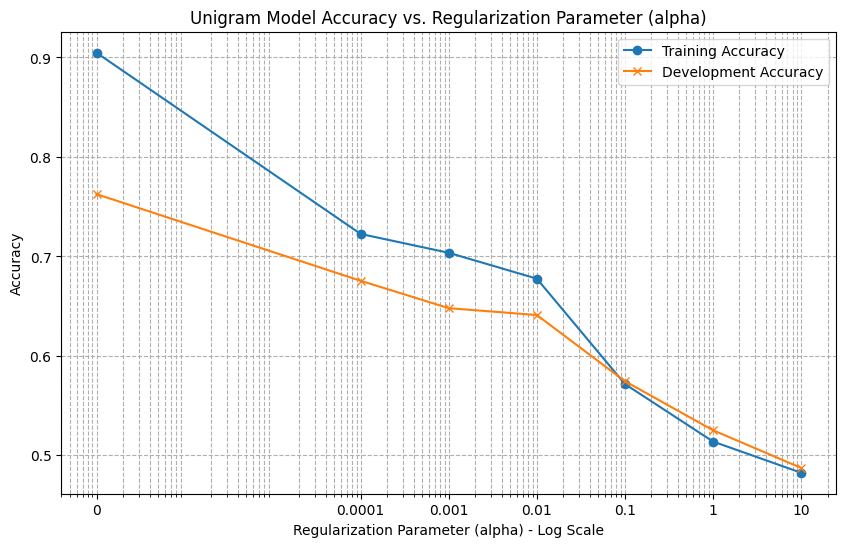

In [12]:
import matplotlib.pyplot as plt

regularization_params = [0, 0.0001, 0.001, 0.01, 0.1, 1, 10]
unigram_train_accuracies_reg = []
unigram_dev_accuracies_reg = []

for alpha in regularization_params:
    print(f"\nTraining Unigram model with regularization parameter (alpha): {alpha}")
    reg_unigram_model = LogisticRegression(data_dim=unigram_vocab_size, reg_param=alpha,
                                       learning_rate=lr, training_tokens=training_unigram_features)

    for epoch in range(epochs):
        reg_unigram_model.SGD_update(stochastic_perc=0.1)

    final_train_acc = reg_unigram_model.accuracy(training_unigram_features)
    final_dev_acc = reg_unigram_model.accuracy(development_unigram_features)

    unigram_train_accuracies_reg.append(final_train_acc)
    unigram_dev_accuracies_reg.append(final_dev_acc)

    print(f"Final Unigram Training Accuracy (alpha={alpha}): {final_train_acc:.4f}")
    print(f"Final Unigram Development Accuracy (alpha={alpha}): {final_dev_acc:.4f}")

# Prepare data for plotting: replace 0 with a small positive number for log scale
plotting_reg_params = [p if p != 0 else 1e-7 for p in regularization_params]

plt.figure(figsize=(10, 6))
plt.plot(plotting_reg_params, unigram_train_accuracies_reg, marker='o', label='Training Accuracy')
plt.plot(plotting_reg_params, unigram_dev_accuracies_reg, marker='x', label='Development Accuracy')
plt.xscale('log') # Set x-axis to logarithmic scale
plt.title('Unigram Model Accuracy vs. Regularization Parameter (alpha)')
plt.xlabel('Regularization Parameter (alpha) - Log Scale')
plt.ylabel('Accuracy')

# Set custom x-ticks to display original labels, including '0'
plt.xticks(plotting_reg_params, labels=[str(p) for p in regularization_params])
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

**(b) Next, we would like to experiment with $l_2$ regularization $R(\theta) = \alpha\|\theta\|^2$. Plot the accuracy on train and development sets as a function of $\alpha = \{0, 10^{-2}, 10^{-1}, 1, 10\}$. You only need to experiment with unigram features for this part. Explain what you observe. Does this match what you would expect from regularization?**

We notice that the effect of regularization on the development accuracy is what we would expect: the accuracy peaks at a non-zero value for the regularization parameter and decreases drastically for high values for it. The training accuracy doesn't change much until the regularization parameter gets too big.

**(c) Based on your model’s performance in the previous experiment, propose one change you would consider
making to either the model or feature extraction pipeline to further improve development set performance.
Briefly describe the modification, explain why you expect it will improve validation perplexity, and discuss any
potential limitations.**

There are many words such as "the," "and," "with," etc. that appear a lot in the datasets but that don't correlate much with either label. But since they're frequently encountered, they will skew the count-based feature vectors of the data (i.e. the values in the dimensions representing those words will be very high). Therefore, unless the model learns to minimize the weights associated with such words as much as possible by itself, their influence on the predicted label will be too high.

As such, one possible improvement could be to dismiss such words altogether when encountering them. This should remove noise from the data and thus improve the development accuracy. A limitation is knowing precisely how many words to disregard.

Another possible improvement could be to reduce the size and the sparsity of the feature vectors by using word embeddings. This would require a pre-training stage where we would obtain the word embeddings of the vocabulary.

# LLM Prompts

If you used an AI tool to complete any part of this assignment, please paste all prompts you used to produce your final code/responses in the box below and answer the following reflection question.

Prompts Used:
*   write me a block of code that explains the py.torch logistic regression main methods, including how to work with hyper parameters, number of epochs, etc. don't connect this to the given tasks in this assignment, I just need it to understand how I could use the py.torch library here
*   why does running the feactureextraction block lead to all my RAM being used
*   what's the ideal number of epochs to use in the gradient descent
*   can you create a loop that creates a unigram model for different values of the regularization parameter: 0, 0.01, 0.1, 1, 10 (same learning rate and epoch number as before) and calculates only the final train and development accuracies and plots them against values of the regularization parameter (make the plot semi-log)
*   the semilog axis is wrong, it plots the results weirdly - do it again, correctly




### Logistic regression with regularization
Code for sub-part (b)

**Reflection: What parts of the AI generated output required modification or improvement? Describe the feedback you gave the tool to produce your final output or any changes you had to make on your own.**

The only part that I noticed on the spot to be wrong was the final graph, but that was because I didn't realize I couldn't plot the 0 value on a log scale accurately, and then the AI assistant figured that out.
Another part that required redesign was the bigram extraction method. Initially, I stored the bigram vectors as very sparse matrices, but when I realized I didn't have enough RAM to store them like that I asked the AI how to solve the issue, and then it suggested using a more efficient data structure for sparse vectors.

## Define Experiment Parameters

### Subtask:
Define a list of approximately 10 learning rate values between 0.0001 and 0.1 (log scale), and a list of three epoch values (100, 500, 1500).


Experiment Learning Rates: ['0.000100', '0.000215', '0.000464', '0.001000', '0.002154', '0.004642', '0.010000', '0.021544', '0.046416', '0.100000']
Experiment Epoch Values: [100, 500, 1500]

Starting Experiment Loop...

Running experiments for 100 epochs...
  Current Learning Rate: 0.000100
    Unigram - Train Acc: 0.6147, Dev Acc: 0.6537
    Bigram  - Train Acc: 0.5545, Dev Acc: 0.5195
  Current Learning Rate: 0.000215
    Unigram - Train Acc: 0.6535, Dev Acc: 0.6823
    Bigram  - Train Acc: 0.6140, Dev Acc: 0.5562
  Current Learning Rate: 0.000464
    Unigram - Train Acc: 0.6908, Dev Acc: 0.7053
    Bigram  - Train Acc: 0.7600, Dev Acc: 0.6296
  Current Learning Rate: 0.001000
    Unigram - Train Acc: 0.7302, Dev Acc: 0.7179
    Bigram  - Train Acc: 0.7405, Dev Acc: 0.6193
  Current Learning Rate: 0.002154
    Unigram - Train Acc: 0.7796, Dev Acc: 0.7385
    Bigram  - Train Acc: 0.8455, Dev Acc: 0.6697
  Current Learning Rate: 0.004642
    Unigram - Train Acc: 0.5368, Dev Acc: 0.5367

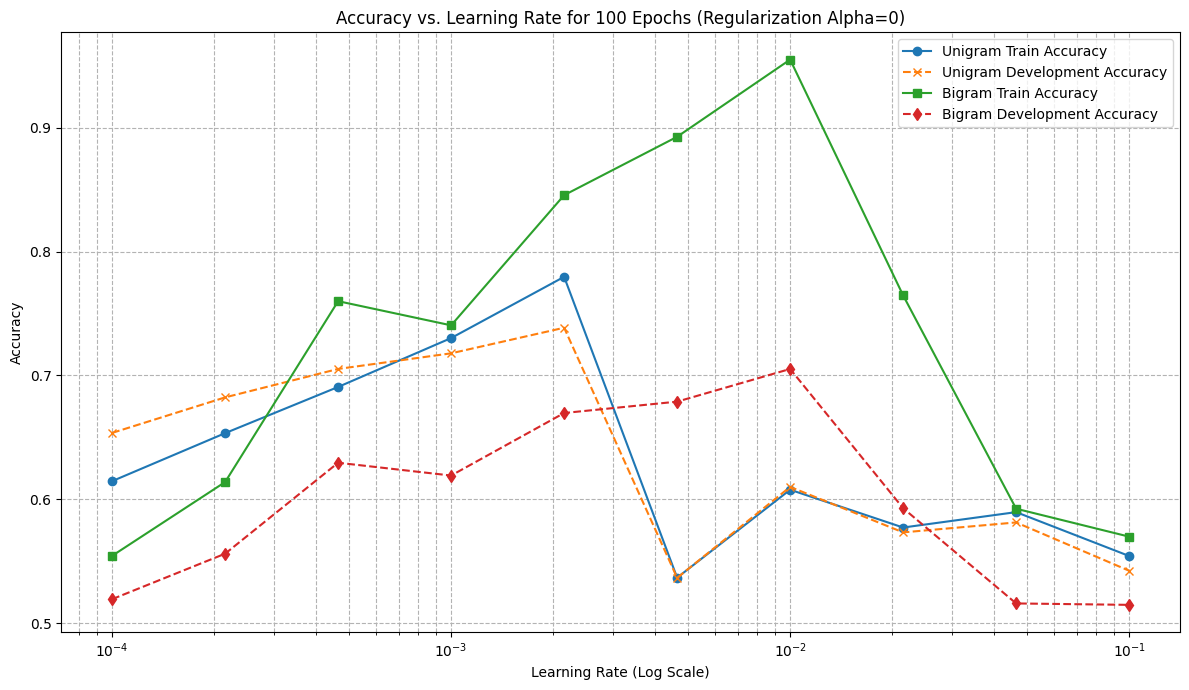

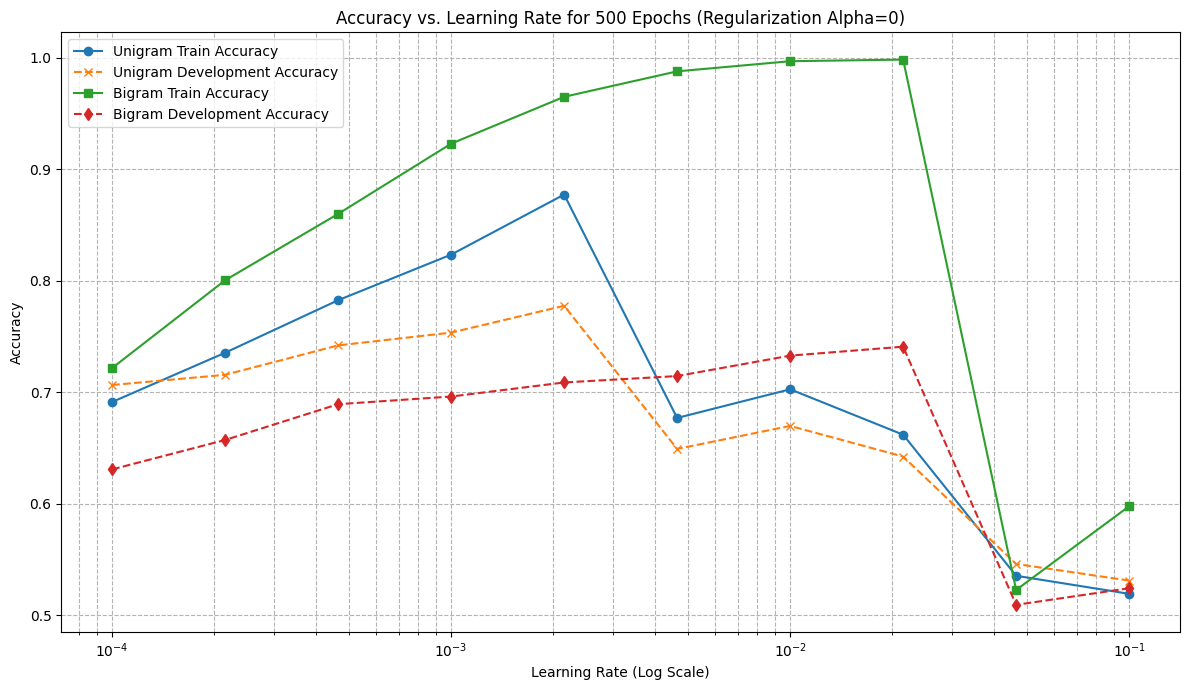

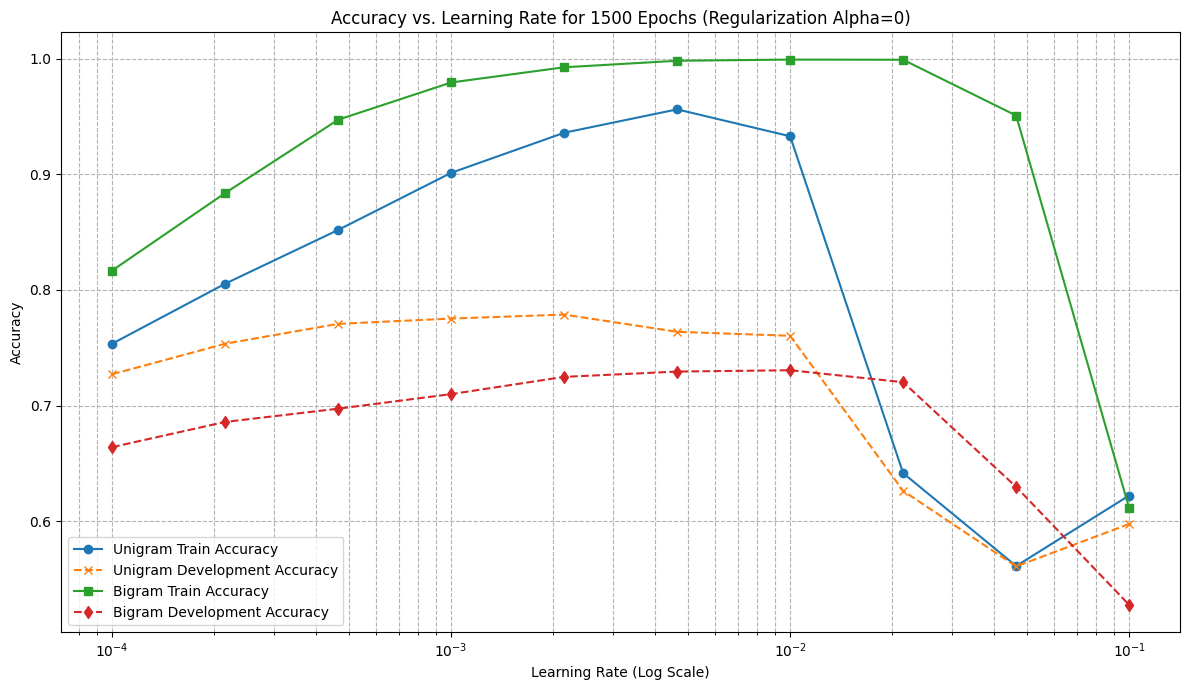


Experiment complete. All plots generated.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp # Ensure scipy.sparse is imported for the LogisticRegression class

# --- Define Experiment Parameters ---
# Define a list of approximately 10 learning rate values between 0.0001 and 0.1 (log scale)
# np.logspace creates evenly spaced numbers on a log scale.
learning_rates = np.logspace(np.log10(0.0001), np.log10(0.1), num=10)
# Define a list of three epoch values
epoch_values = [100, 500, 1500] # Example epoch values as specified

print("Experiment Learning Rates:", [f"{lr:.6f}" for lr in learning_rates])
print("Experiment Epoch Values:", epoch_values)

# --- Initialize Result Storage ---
# Dictionaries to store final training and development accuracies for each epoch and learning rate combination.
# Structure: {epoch_val: {'unigram_train': [acc_lr1, acc_lr2, ...], 'unigram_dev': [...], 'bigram_train': [...], 'bigram_dev': [...]}}
results = {
    epoch: {
        'unigram_train': [],
        'unigram_dev': [],
        'bigram_train': [],
        'bigram_dev': []
    } for epoch in epoch_values
}

# Fixed regularization parameter as per the task (alpha=0)
fixed_reg_param = 0.1
# Stochastic percentage for SGD update (using the value from previous experiments in the notebook)
stochastic_perc_value = 0.1

# --- Run Experiment Loop ---
print("\nStarting Experiment Loop...")
for num_epochs in epoch_values:
    print(f"\nRunning experiments for {num_epochs} epochs...")
    for lr in learning_rates:
        print(f"  Current Learning Rate: {lr:.6f}")

        # --- Unigram Model Experiment ---
        # 1. Instantiate a new LogisticRegression model for unigram features
        # Pass the pre-extracted unigram features for training.
        unigram_model = LogisticRegression(
            data_dim=unigram_vocab_size,
            reg_param=fixed_reg_param, # Alpha is fixed to 0 for this experiment
            learning_rate=lr,
            training_tokens=training_unigram_features
        )

        # 2. Train the unigram model for the specified number of epochs
        for _ in range(num_epochs):
            unigram_model.SGD_update(stochastic_perc=stochastic_perc_value)

        # 3. Calculate and store the final training and development accuracies for the unigram model
        final_unigram_train_accuracy = unigram_model.accuracy(training_unigram_features)
        final_unigram_dev_accuracy = unigram_model.accuracy(development_unigram_features)

        results[num_epochs]['unigram_train'].append(final_unigram_train_accuracy)
        results[num_epochs]['unigram_dev'].append(final_unigram_dev_accuracy)

        # --- Bigram Model Experiment ---
        # 4. Repeat steps 1-3 for the bigram model
        # Instantiate a new LogisticRegression model for bigram features
        # Pass the pre-extracted bigram features for training.
        bigram_model = LogisticRegression(
            data_dim=bigram_vocab_size,
            reg_param=fixed_reg_param, # Alpha is fixed to 0 for this experiment
            learning_rate=lr,
            training_tokens=training_bigram_features
        )

        # Train the bigram model for the specified number of epochs
        for _ in range(num_epochs):
            bigram_model.SGD_update(stochastic_perc=stochastic_perc_value)

        # Calculate and store the final training and development accuracies for the bigram model
        final_bigram_train_accuracy = bigram_model.accuracy(training_bigram_features)
        final_bigram_dev_accuracy = bigram_model.accuracy(development_bigram_features)

        results[num_epochs]['bigram_train'].append(final_bigram_train_accuracy)
        results[num_epochs]['bigram_dev'].append(final_bigram_dev_accuracy)

        print(f"    Unigram - Train Acc: {final_unigram_train_accuracy:.4f}, Dev Acc: {final_unigram_dev_accuracy:.4f}")
        print(f"    Bigram  - Train Acc: {final_bigram_train_accuracy:.4f}, Dev Acc: {final_bigram_dev_accuracy:.4f}")

# --- Generate Accuracy Plots ---
print("\nGenerating accuracy plots...")
for num_epochs in epoch_values:
    plt.figure(figsize=(12, 7))

    # Plot unigram accuracies
    plt.plot(learning_rates, results[num_epochs]['unigram_train'], marker='o', linestyle='-', label='Unigram Train Accuracy')
    plt.plot(learning_rates, results[num_epochs]['unigram_dev'], marker='x', linestyle='--', label='Unigram Development Accuracy')

    # Plot bigram accuracies
    plt.plot(learning_rates, results[num_epochs]['bigram_train'], marker='s', linestyle='-', label='Bigram Train Accuracy')
    plt.plot(learning_rates, results[num_epochs]['bigram_dev'], marker='d', linestyle='--', label='Bigram Development Accuracy')

    plt.xscale('log') # Set x-axis (learning rate) to logarithmic scale
    plt.title(f'Accuracy vs. Learning Rate for {num_epochs} Epochs (Regularization Alpha=0)')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Accuracy')
    plt.grid(True, which="both", ls="--", c='0.7') # Add grid for better readability
    plt.legend() # Display legend to differentiate lines
    plt.tight_layout() # Adjust plot to prevent labels from overlapping
    plt.show()

print("\nExperiment complete. All plots generated.")

**Reasoning**:
The subtask requires defining `learning_rates` using `np.logspace` and `epoch_values` as a list, then printing them. This code block will accomplish that.



In [21]:
import numpy as np

# 1. Define learning_rates using np.logspace
learning_rates = np.logspace(np.log10(0.0001), np.log10(0.1), 10)

# 2. Define epoch_values as a list
epoch_values = [100, 500, 1500]

# 3. Print the defined variables
print(f"Defined learning rates (log scale from 0.0001 to 0.1):\n{learning_rates}")
print(f"Defined epoch values: {epoch_values}")

Defined learning rates (log scale from 0.0001 to 0.1):
[0.0001     0.00021544 0.00046416 0.001      0.00215443 0.00464159
 0.01       0.02154435 0.04641589 0.1       ]
Defined epoch values: [100, 500, 1500]


**Reasoning**:
The next step is to initialize the result storage to collect accuracies for unigram and bigram models across different epoch and learning rate combinations, as outlined in the initial `Task` code block.



In [22]:
fixed_reg_param = 0
stochastic_perc_value = 0.1

# Dictionaries to store final training and development accuracies for each epoch and learning rate combination.
# Structure: {epoch_val: {'unigram_train': [acc_lr1, acc_lr2, ...], 'unigram_dev': [...], 'bigram_train': [...], 'bigram_dev': [...]}}
results = {
    epoch: {
        'unigram_train': [],
        'unigram_dev': [],
        'bigram_train': [],
        'bigram_dev': []
    } for epoch in epoch_values
}

print("Initialized result storage and experiment parameters (fixed_reg_param, stochastic_perc_value).")

Initialized result storage and experiment parameters (fixed_reg_param, stochastic_perc_value).


**Reasoning**:
The next step is to implement the main experiment loop where models are trained and evaluated for each combination of epoch values and learning rates, storing the results for plotting, as per the overall task description.



In [23]:
print("\nStarting Experiment Loop...")
for num_epochs in epoch_values:
    print(f"\nRunning experiments for {num_epochs} epochs...")
    for lr in learning_rates:
        print(f"  Current Learning Rate: {lr:.6f}")

        # --- Unigram Model Experiment ---
        # Instantiate a new LogisticRegression model for unigram features
        unigram_model = LogisticRegression(
            data_dim=unigram_vocab_size,
            reg_param=fixed_reg_param,
            learning_rate=lr,
            training_tokens=training_unigram_features
        )

        # Train the unigram model for the specified number of epochs
        for _ in range(num_epochs):
            unigram_model.SGD_update(stochastic_perc=stochastic_perc_value)

        # Calculate and store the final training and development accuracies for the unigram model
        final_unigram_train_accuracy = unigram_model.accuracy(training_unigram_features)
        final_unigram_dev_accuracy = unigram_model.accuracy(development_unigram_features)

        results[num_epochs]['unigram_train'].append(final_unigram_train_accuracy)
        results[num_epochs]['unigram_dev'].append(final_unigram_dev_accuracy)

        # --- Bigram Model Experiment ---
        # Instantiate a new LogisticRegression model for bigram features
        bigram_model = LogisticRegression(
            data_dim=bigram_vocab_size,
            reg_param=fixed_reg_param,
            learning_rate=lr,
            training_tokens=training_bigram_features
        )

        # Train the bigram model for the specified number of epochs
        for _ in range(num_epochs):
            bigram_model.SGD_update(stochastic_perc=stochastic_perc_value)

        # Calculate and store the final training and development accuracies for the bigram model
        final_bigram_train_accuracy = bigram_model.accuracy(training_bigram_features)
        final_bigram_dev_accuracy = bigram_model.accuracy(development_bigram_features)

        results[num_epochs]['bigram_train'].append(final_bigram_train_accuracy)
        results[num_epochs]['bigram_dev'].append(final_bigram_dev_accuracy)

        print(f"    Unigram - Train Acc: {final_unigram_train_accuracy:.4f}, Dev Acc: {final_unigram_dev_accuracy:.4f}")
        print(f"    Bigram  - Train Acc: {final_bigram_train_accuracy:.4f}, Dev Acc: {final_bigram_dev_accuracy:.4f}")


Starting Experiment Loop...

Running experiments for 100 epochs...
  Current Learning Rate: 0.000100
    Unigram - Train Acc: 0.6220, Dev Acc: 0.6399
    Bigram  - Train Acc: 0.5523, Dev Acc: 0.5218
  Current Learning Rate: 0.000215
    Unigram - Train Acc: 0.6503, Dev Acc: 0.6606
    Bigram  - Train Acc: 0.5785, Dev Acc: 0.5218
  Current Learning Rate: 0.000464
    Unigram - Train Acc: 0.6918, Dev Acc: 0.7030
    Bigram  - Train Acc: 0.7186, Dev Acc: 0.6158
  Current Learning Rate: 0.001000
    Unigram - Train Acc: 0.7259, Dev Acc: 0.7076
    Bigram  - Train Acc: 0.8013, Dev Acc: 0.6525
  Current Learning Rate: 0.002154
    Unigram - Train Acc: 0.7733, Dev Acc: 0.7408
    Bigram  - Train Acc: 0.8238, Dev Acc: 0.6468
  Current Learning Rate: 0.004642
    Unigram - Train Acc: 0.5798, Dev Acc: 0.5711
    Bigram  - Train Acc: 0.9178, Dev Acc: 0.7064
  Current Learning Rate: 0.010000
    Unigram - Train Acc: 0.5357, Dev Acc: 0.5413
    Bigram  - Train Acc: 0.9395, Dev Acc: 0.6800
  Curren

**Reasoning**:
The experiment loop has finished execution and the results are stored in the `results` dictionary. The next step is to generate the plots as described in the overall `Task` markdown cell, visualizing the accuracies against learning rates for each epoch value.




Generating accuracy plots...


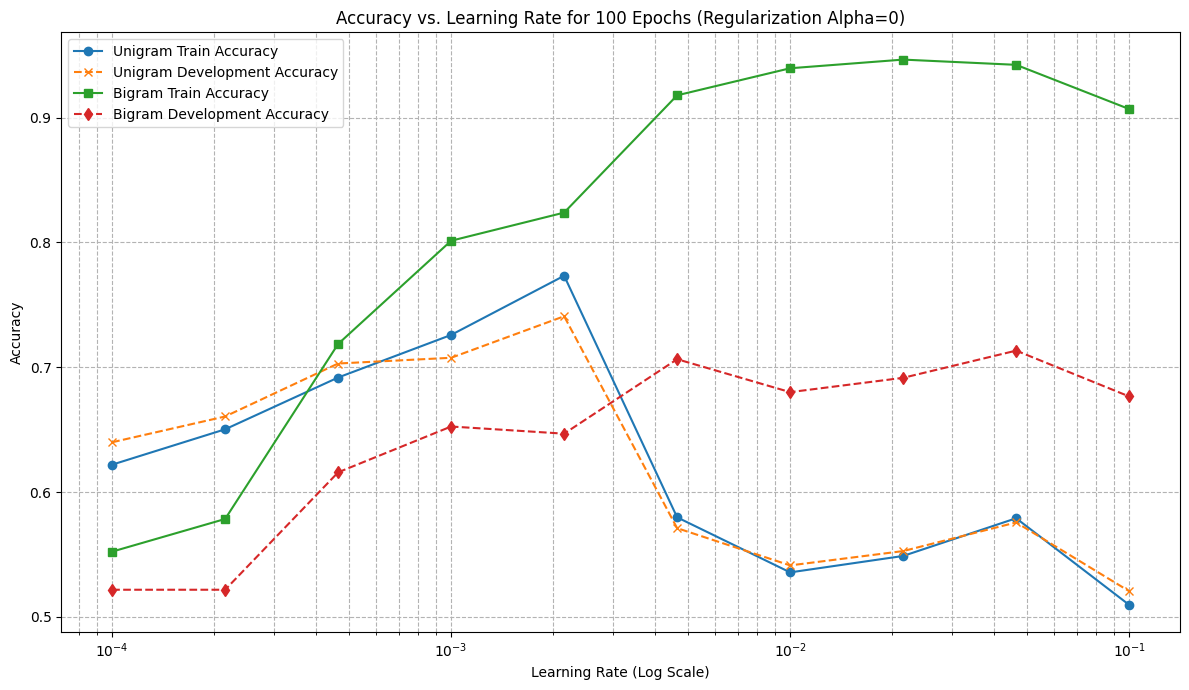

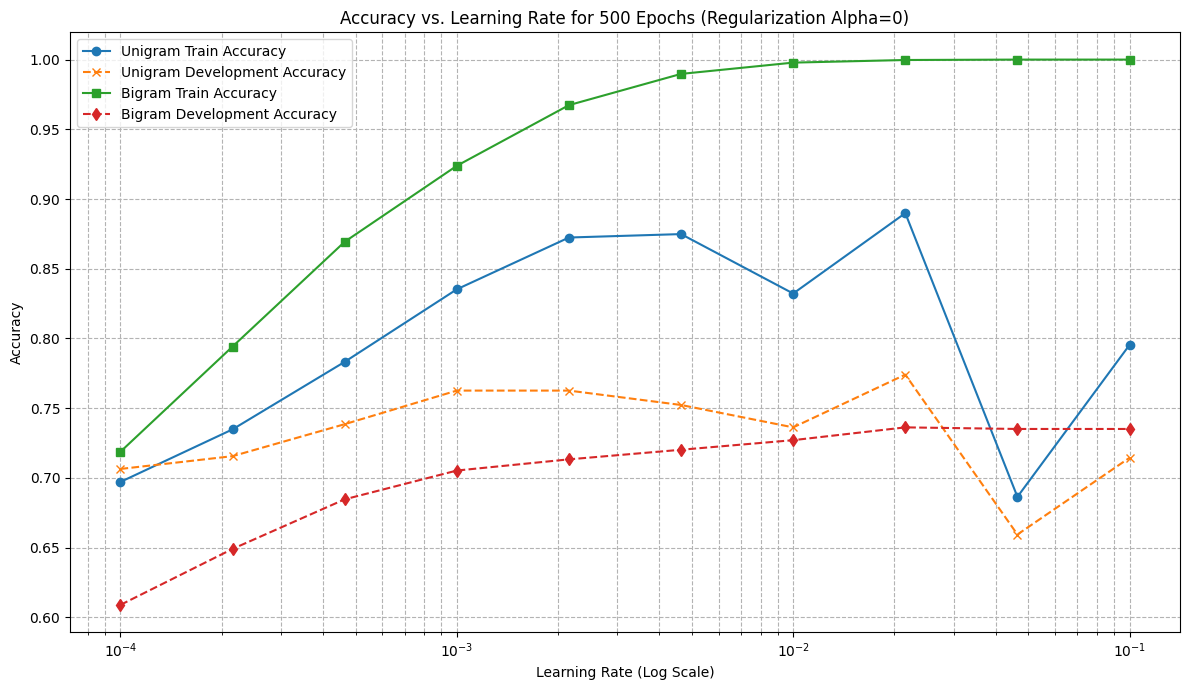

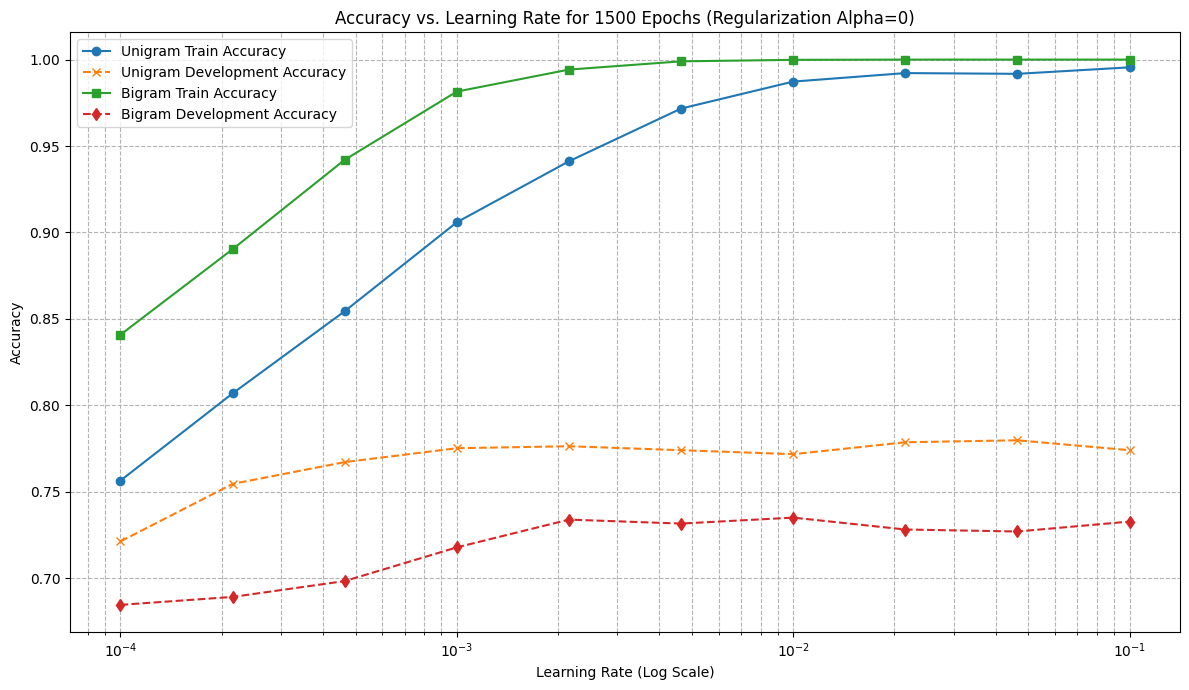


Experiment complete. All plots generated.


In [24]:
import matplotlib.pyplot as plt

print("\nGenerating accuracy plots...")
for num_epochs in epoch_values:
    plt.figure(figsize=(12, 7))

    # Plot unigram accuracies
    plt.plot(learning_rates, results[num_epochs]['unigram_train'], marker='o', linestyle='-', label='Unigram Train Accuracy')
    plt.plot(learning_rates, results[num_epochs]['unigram_dev'], marker='x', linestyle='--', label='Unigram Development Accuracy')

    # Plot bigram accuracies
    plt.plot(learning_rates, results[num_epochs]['bigram_train'], marker='s', linestyle='-', label='Bigram Train Accuracy')
    plt.plot(learning_rates, results[num_epochs]['bigram_dev'], marker='d', linestyle='--', label='Bigram Development Accuracy')

    plt.xscale('log') # Set x-axis (learning rate) to logarithmic scale
    plt.title(f'Accuracy vs. Learning Rate for {num_epochs} Epochs (Regularization Alpha=0)')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Accuracy')
    plt.grid(True, which="both", ls="--", c='0.7') # Add grid for better readability
    plt.legend() # Display legend to differentiate lines
    plt.tight_layout() # Adjust plot to prevent labels from overlapping
    plt.show()

print("\nExperiment complete. All plots generated.")

## Final Task

### Subtask:
Present the generated and commented code for the experiment.


## Summary:

### Data Analysis Key Findings
*   The experiment defined 10 logarithmically spaced learning rates ranging from 0.0001 to 0.1 and evaluated model performance across three epoch values: 100, 500, and 1500.
*   A fixed regularization parameter (\$\alpha\$) of 0 and a stochastic percentage of 0.1 for SGD updates were used throughout the experiment.
*   For each combination of epochs and learning rates, both unigram and bigram Logistic Regression models were trained, and their final training and development accuracies were recorded.
*   The results were visualized in plots that demonstrate the relationship between accuracy and learning rate for each specified number of epochs, allowing for a comparative analysis of unigram and bigram model performance.

### Insights or Next Steps
*   Analyze the generated plots to identify the optimal learning rates and epoch counts that yield the highest development accuracies for both unigram and bigram models.
*   Investigate the impact of the regularization parameter (\$\alpha\$) by running similar experiments with different \$\alpha\$ values to see if it improves generalization performance or mitigates overfitting.
